In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linearmodel import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler_

In [7]:
df=pd.read_csv('/content/ott_viewer_dropoff_retention_us_v1.0.csv')
df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,...,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,...,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,...,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,...,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,...,3,0,1,7,high,0,1,0.638,high,v1.0


In [8]:
df.drop(['dataset_version'], inplace=True, axis=True)
df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,...,39,3,0,0,9,high,0,1,0.649,high
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,...,55,3,3,1,5,medium,0,0,0.473,medium
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,...,46,4,2,0,9,high,0,0,0.583,medium
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,...,50,4,1,0,7,high,0,0,0.520,medium
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,...,35,3,0,1,7,high,0,1,0.638,high


In [9]:
df.describe()

,show_id,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,night_watch_safe,drop_off,drop_off_probability
count,33171.000000,33171.000000,33171.0,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000
mean,63698.539688,2000.739743,1.0,423.718881,37.660667,5.397908,5.525158,6.009436,56.805764,3.102921,2.003497,0.493262,6.196015,0.015887,0.144825,0.478433
std,65206.256887,15.750470,0.0,557.688460,22.899741,1.230418,1.730098,1.994370,12.577000,1.866938,1.548391,0.499962,1.322146,0.125042,0.351930,0.107382
min,36.000000,1952.000000,1.0,1.000000,1.000000,3.000000,3.000000,3.000000,13.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.120000
25%,15226.000000,1992.000000,1.0,27.000000,24.000000,4.000000,4.000000,4.000000,48.000000,2.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.400000
50%,35024.000000,2004.000000,1.0,178.000000,33.000000,5.000000,6.000000,6.000000,57.000000,3.000000,2.000000,0.000000,7.000000,0.000000,0.000000,0.471000
75%,80885.000000,2012.000000,1.0,611.000000,49.000000,6.000000,7.000000,8.000000,66.000000,4.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.553000
max,305062.000000,2025.000000,1.0,2650.000000,1225.000000,8.000000,10.000000,9.000000,100.000000,10.000000,8.000000,1.000000,9.000000,1.000000,1.000000,0.831000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  object 
 2   platform              33171 non-null  object 
 3   genre                 33171 non-null  object 
 4   release_year          33171 non-null  float64
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  object 
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro         

In [11]:
df.isnull().sum()

,0
show_id,0
title,0
platform,0
genre,0
release_year,0
season_number,0
episode_number,0
episode_duration_min,0
pacing_score,0
hook_strength,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.loc[5:15, 'episode_duration_min'] = np.nan
df.loc[25:39, 'avg_watch_percentage'] = np.nan
df.loc[22:30, 'attention_required'] = np.nan
df.loc[80:120, 'visual_intensity'] = np.nan


In [14]:
df.isnull().sum()

,0
show_id,0
title,0
platform,0
genre,0
release_year,0
season_number,0
episode_number,0
episode_duration_min,11
pacing_score,0
hook_strength,0


In [15]:
# mean imputation

mean_imputer  = SimpleImputer(strategy='mean')
df['episode_duration_min'] = mean_imputer.fit_transform(df[['episode_duration_min']])


In [16]:
# median imputation

median_imputer = SimpleImputer(strategy='median')
df['avg_watch_percentage'] = median_imputer.fit_transform(df[['avg_watch_percentage']])

In [17]:
# mode imputation

mode_imputer = SimpleImputer(strategy='most_frequent')
df['attention_required'] = mode_imputer.fit_transform(df[['attention_required']]).ravel()

In [18]:
# KNN imputation

knn_imputer = KNNImputer(n_neighbors=5)   #The missing value is filled using 5 most similar records
df['visual_intensity'] = knn_imputer.fit_transform(df[['visual_intensity']]).ravel()

In [19]:
df.isnull().sum()

,0
show_id,0
title,0
platform,0
genre,0
release_year,0
season_number,0
episode_number,0
episode_duration_min,0
pacing_score,0
hook_strength,0


In [20]:
df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48.0,4,5,...,39.0,3,0,0,9,high,0,1,0.649,high
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55.0,5,4,...,55.0,3,3,1,5,medium,0,0,0.473,medium
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51.0,4,8,...,46.0,4,2,0,9,high,0,0,0.583,medium
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50.0,4,7,...,50.0,4,1,0,7,high,0,0,0.520,medium
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52.0,4,3,...,35.0,3,0,1,7,high,0,1,0.638,high


In [21]:
df['release_year'] = df['release_year'].astype(int)
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y')
df['episode_duration_min'] = df['episode_duration_min'].astype(int).astype(str) + ' minutes'
df['avg_watch_percentage'] = df['avg_watch_percentage'].astype(int)
# reflection of above changes
# conversion into appropriate type

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   show_id               33171 non-null  int64         
 1   title                 33171 non-null  object        
 2   platform              33171 non-null  object        
 3   genre                 33171 non-null  object        
 4   release_year          33171 non-null  datetime64[ns]
 5   season_number         33171 non-null  int64         
 6   episode_number        33171 non-null  int64         
 7   episode_duration_min  33171 non-null  object        
 8   pacing_score          33171 non-null  int64         
 9   hook_strength         33171 non-null  int64         
 10  dialogue_density      33171 non-null  object        
 11  visual_intensity      33171 non-null  float64       
 12  avg_watch_percentage  33171 non-null  int64         
 13  pause_count     

In [22]:
# reflection of above changes
df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,1,48 minutes,4,5,...,39,3,0,0,9,high,0,1,0.649,high
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,2,55 minutes,5,4,...,55,3,3,1,5,medium,0,0,0.473,medium
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,3,51 minutes,4,8,...,46,4,2,0,9,high,0,0,0.583,medium
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,4,50 minutes,4,7,...,50,4,1,0,7,high,0,0,0.520,medium
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,5,52 minutes,4,3,...,35,3,0,1,7,high,0,1,0.638,high


In [23]:
# Define a custom mapping for 'low', 'medium', and 'high'
mapping = {'medium': 0, 'high': 1}
mapping2 = {'low': 0,'medium' : 1, 'high': 2}

# Apply the custom mapping to the relevant columns
df['attention_required'] = df['attention_required'].map(mapping)
df['dialogue_density'] = df['dialogue_density'].map(mapping2)
df['retention_risk'] = df['retention_risk'].map(mapping2)

In [24]:
df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,1,48 minutes,4,5,...,39,3,0,0,9,1,0,1,0.649,2
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,2,55 minutes,5,4,...,55,3,3,1,5,0,0,0,0.473,1
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,3,51 minutes,4,8,...,46,4,2,0,9,1,0,0,0.583,1
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,4,50 minutes,4,7,...,50,4,1,0,7,1,0,0,0.520,1
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,5,52 minutes,4,3,...,35,3,0,1,7,1,0,1,0.638,2


In [25]:
from sklearn.preprocessing import StandardScaler

# Convert 'episode_duration_min' back to numeric
df['episode_duration_min'] = df['episode_duration_min'].str.replace(' minutes', '').astype(int)

# Apply StandardScaler
scaler = StandardScaler()
df['episode_duration_min'] = scaler.fit_transform(df[['episode_duration_min']])

df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,1,0.451867,4,5,...,39,3,0,0,9,1,0,1,0.649,2
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,2,0.757594,5,4,...,55,3,3,1,5,0,0,0,0.473,1
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,3,0.582893,4,8,...,46,4,2,0,9,1,0,0,0.583,1
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,4,0.539217,4,7,...,50,4,1,0,7,1,0,0,0.520,1
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,5,0.626568,4,3,...,35,3,0,1,7,1,0,1,0.638,2


In [26]:
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler to 'hook_strength'
minmax_scaler = MinMaxScaler()
df['hook_strength'] = minmax_scaler.fit_transform(df[['hook_strength']])

df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,1,0.451867,4,0.285714,...,39,3,0,0,9,1,0,1,0.649,2
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,2,0.757594,5,0.142857,...,55,3,3,1,5,0,0,0,0.473,1
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,3,0.582893,4,0.714286,...,46,4,2,0,9,1,0,0,0.583,1
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,4,0.539217,4,0.571429,...,50,4,1,0,7,1,0,0,0.520,1
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016-01-01,1,5,0.626568,4,0.000000,...,35,3,0,1,7,1,0,1,0.638,2


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Identify target variable
y = df['drop_off_probability']


# Exclude identifying columns and direct target-related columns
features_to_drop = [
    'show_id',
    'title',
    'drop_off', # Directly related to drop_off_probability
    'drop_off_probability', # The target itself


]

X = df.drop(columns=features_to_drop).copy() # Use .copy() to avoid SettingWithCopyWarning

# Process 'release_year' - extract year as an integer
X['release_year'] = X['release_year'].dt.year



# Handle categorical features using one-hot encoding
categorical_cols = ['platform', 'genre', 'dialogue_density', 'attention_required'] # Added dialogue_density and attention_required
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [28]:


# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Linear Regression Root Mean Squared Error (RMSE): {rmse_lr:.4f}")

Linear Regression Mean Absolute Error (MAE): 0.0003
Linear Regression Mean Squared Error (MSE): 0.0000
Linear Regression Root Mean Squared Error (RMSE): 0.0011


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"Random Forest Regressor Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Random Forest Regressor Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Random Forest Regressor Root Mean Squared Error (RMSE): {rmse_rf:.4f}")

Random Forest Regressor Mean Absolute Error (MAE): 0.0010
Random Forest Regressor Mean Squared Error (MSE): 0.0000
Random Forest Regressor Root Mean Squared Error (RMSE): 0.0031


In [30]:
print("\n--- Model Comparison ---")
print(f"Linear Regression MAE: {mae_lr:.4f}")
print(f"Linear Regression MSE: {rmse_lr:.4f}")
print(f"Random Forest Regressor MAE: {mae_rf:.4f}")
print(f"Random Forest Regressor MSE: {rmse_rf:.4f}")


--- Model Comparison ---
Linear Regression MAE: 0.0003
Linear Regression MSE: 0.0011
Random Forest Regressor MAE: 0.0010
Random Forest Regressor MSE: 0.0031


/tmp/ipykernel_932/2227501603.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='genre', palette='viridis', order=df['genre'].value_counts().index)


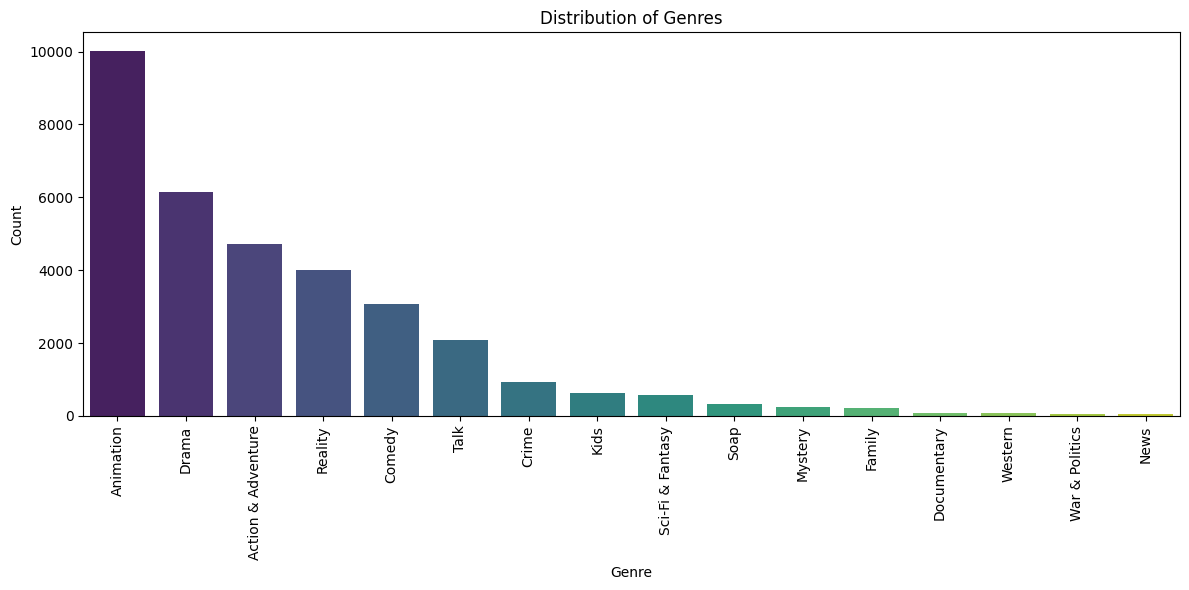

In [31]:
# Set the figure size for better readability of the plot
plt.figure(figsize=(12, 6))
# Create a count plot to visualize the distribution of different genres
# 'data' specifies the DataFrame to use
# 'x' specifies the column for the x-axis, which is 'genre'
# 'palette' sets the color scheme for the bars
# 'order' ensures the bars are sorted by the count of each genre in descending order
sns.countplot(data=df, x='genre', palette='viridis', order=df['genre'].value_counts().index)
# Set the title of the plot
plt.title('Distribution of Genres')
# Set the label for the x-axis
plt.xlabel('Genre')
# Set the label for the y-axis
plt.ylabel('Count')
# Rotate the x-axis labels by 90 degrees to prevent overlap
plt.xticks(rotation=90)
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()

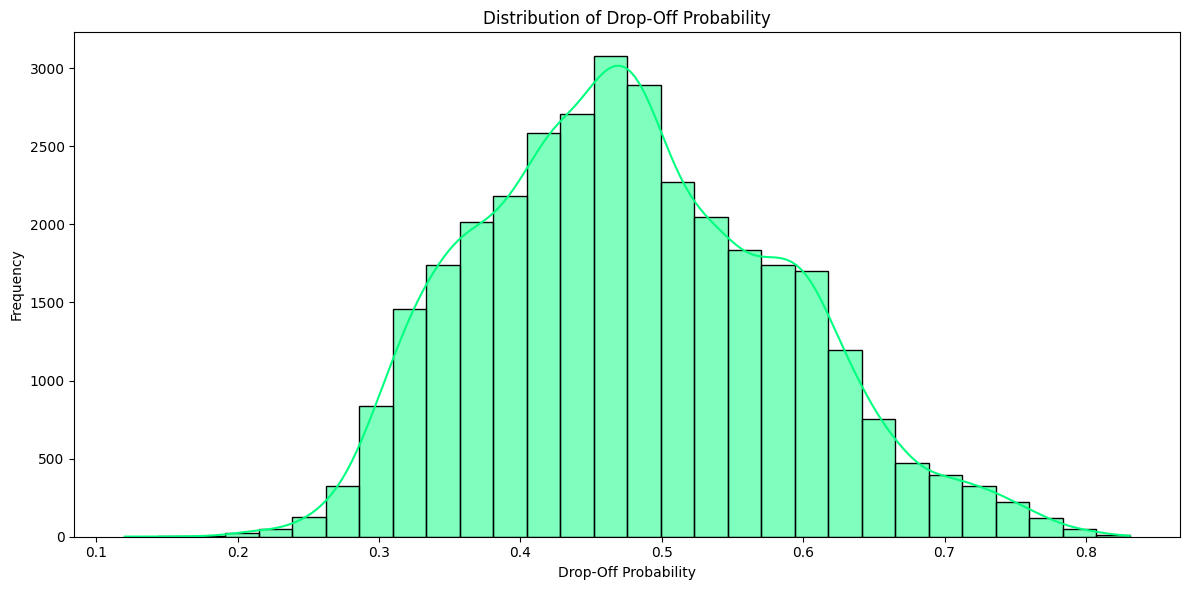

In [32]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='drop_off_probability', bins=30, kde=True, color='springgreen') # Create a histogram with a Kernel Density Estimate (KDE) line
plt.title('Distribution of Drop-Off Probability') # Set the title of the plot
plt.xlabel('Drop-Off Probability') # Set the label for the x-axis
plt.ylabel('Frequency') # Set the label for the y-axis
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

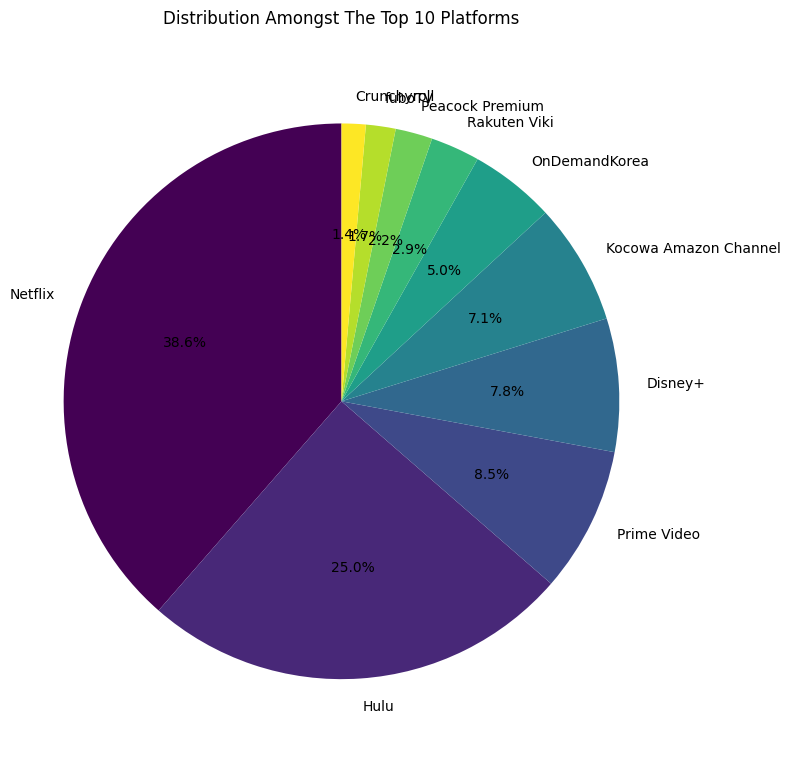

In [33]:
plt.figure(figsize=(8, 8))
platform_counts = df['platform'].value_counts().head(10) # Get the top 10 platforms by count
plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.viridis(np.linspace(0, 1, len(platform_counts)))) # Create a pie chart
plt.title('Distribution Amongst The Top 10 Platforms') # Set the title of the plot
plt.axis('equal') # Ensure the pie chart is circular
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

/tmp/ipykernel_932/4145826648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='drop_off_probability', y='genre', palette='viridis') # Create a box plot


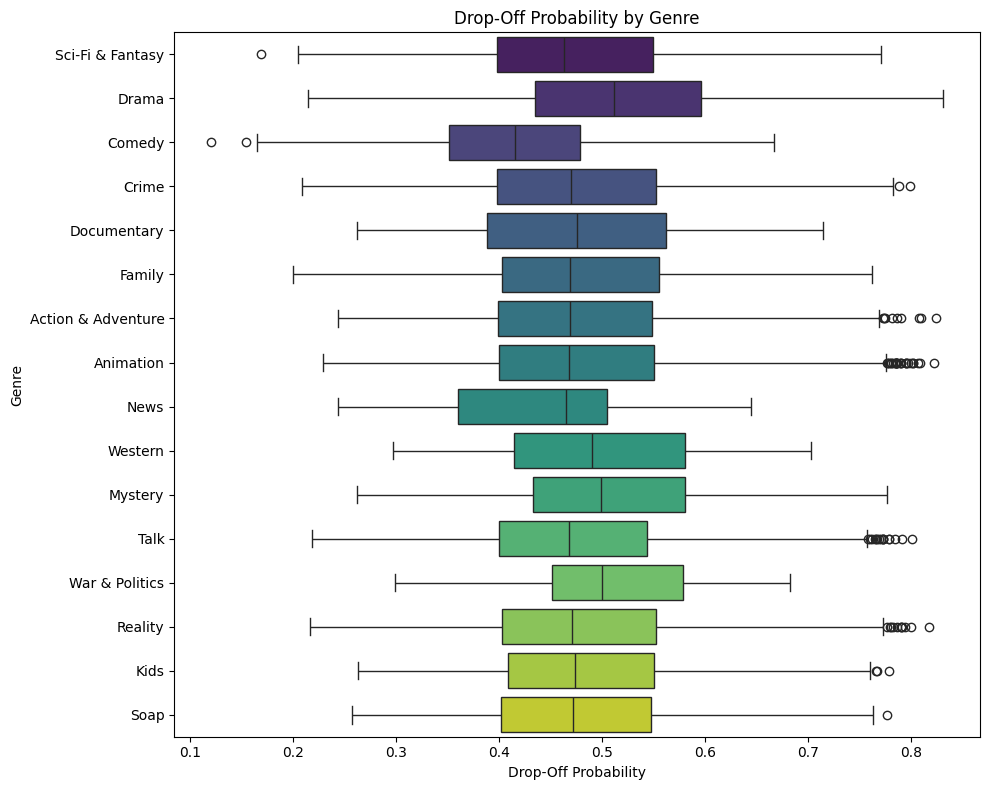

In [34]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='drop_off_probability', y='genre', palette='viridis') # Create a box plot
plt.title('Drop-Off Probability by Genre') # Set the title of the plot
plt.xlabel('Drop-Off Probability') # Set the label for the x-axis
plt.ylabel('Genre') # Set the label for the y-axis
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

/tmp/ipykernel_932/477290898.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='pacing_score', y='drop_off_probability', palette='viridis', alpha=0.6) # Create a scatter plot to visualize the relationship between 'pacing_score' and 'drop_off_probability'


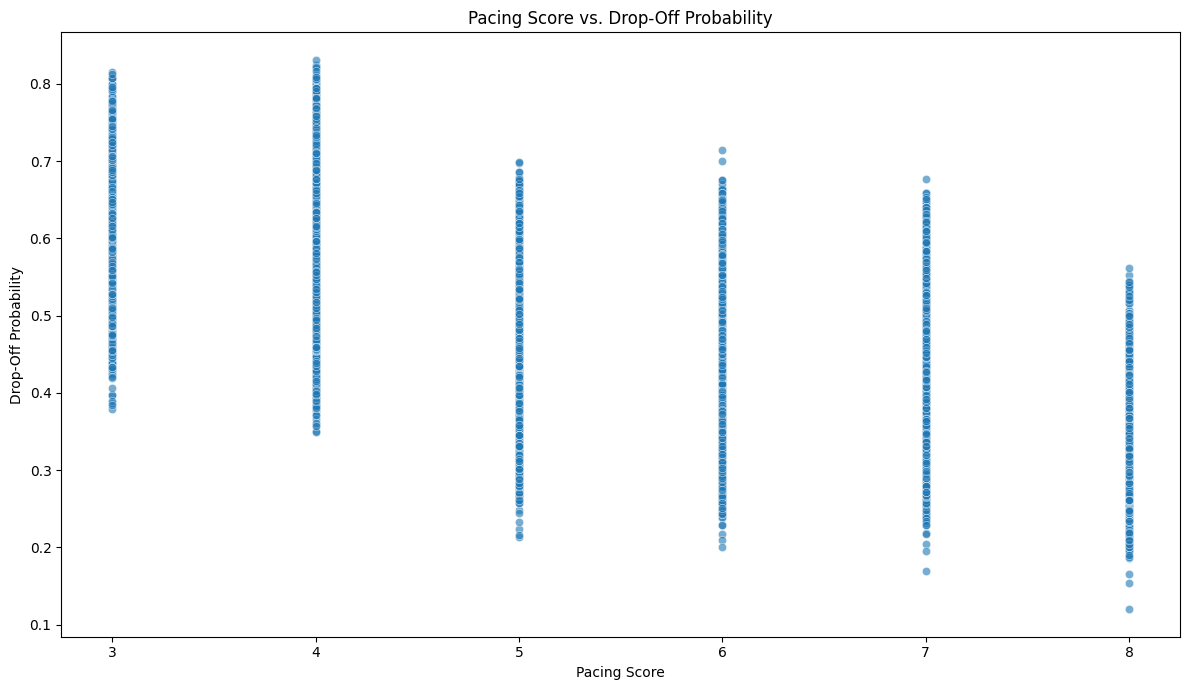

In [35]:
plt.figure(figsize=(12, 7)) # Set the figure size for the plot
sns.scatterplot(data=df, x='pacing_score', y='drop_off_probability', palette='viridis', alpha=0.6) # Create a scatter plot to visualize the relationship between 'pacing_score' and 'drop_off_probability'
plt.title('Pacing Score vs. Drop-Off Probability') # Set the title of the plot
plt.xlabel('Pacing Score') # Set the label for the x-axis
plt.ylabel('Drop-Off Probability') # Set the label for the y-axis
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

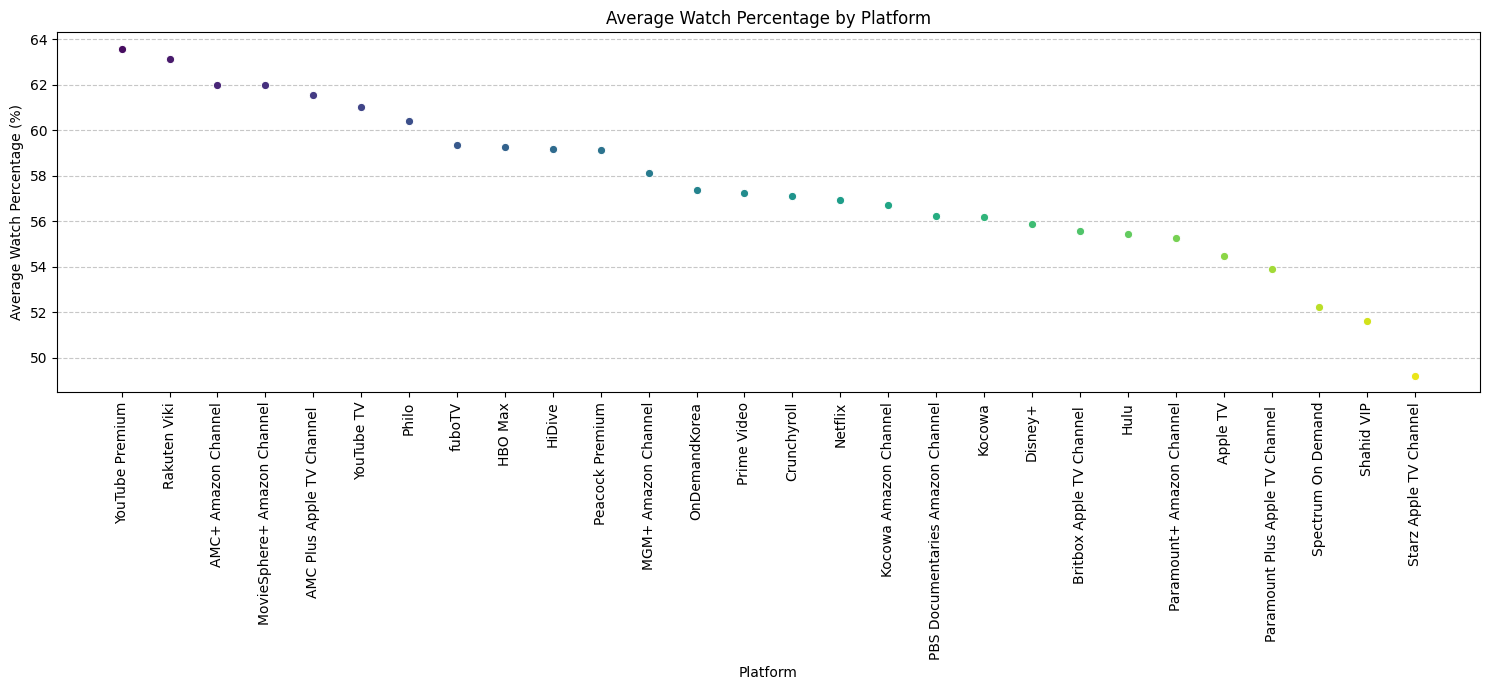

In [36]:

# Calculate the average watch percentage grouped by platform
platform_avg_watch = df.groupby('platform')['avg_watch_percentage'].mean().reset_index()
# Sort the platforms by average watch percentage in descending order
platform_avg_watch_sorted = platform_avg_watch.sort_values(by='avg_watch_percentage', ascending=False)

# Set the figure size for the plot
plt.figure(figsize=(15, 7))
# Create a line plot to visualize the average watch percentage by platform
sns.lineplot(data=platform_avg_watch_sorted, x='platform', y='avg_watch_percentage', marker='o', palette='viridis', hue='platform', legend=False)
# Set the title of the plot
plt.title('Average Watch Percentage by Platform')
# Set the label for the x-axis
plt.xlabel('Platform')
# Set the label for the y-axis
plt.ylabel('Average Watch Percentage (%)')
# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)
# Add a grid to the y-axis for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()

/tmp/ipykernel_932/2595834990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attention_required', y='drop_off_probability', palette='cividis', showmeans=True, meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"})


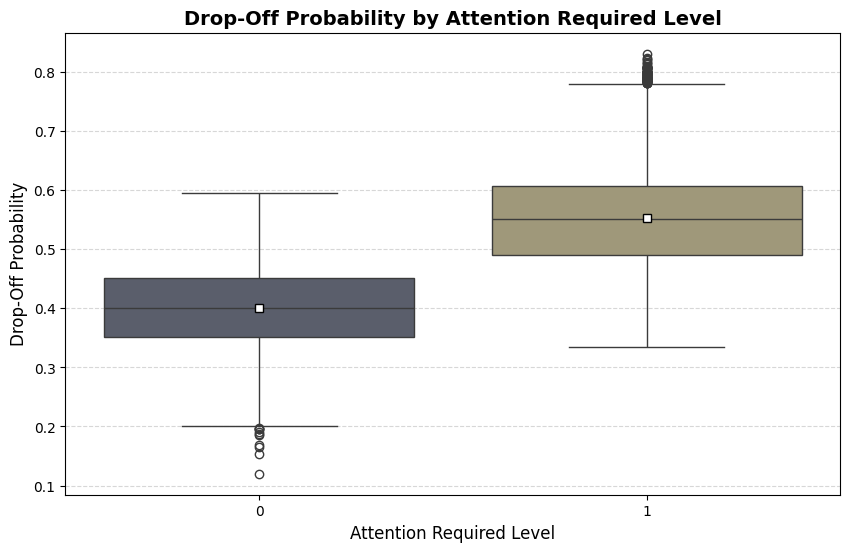

In [37]:
plt.figure(figsize=(10, 6))

# Create a box plot to visualize the distribution of 'drop_off_probability' across different 'attention_required' levels
sns.boxplot(data=df, x='attention_required', y='drop_off_probability', palette='cividis', showmeans=True, meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"})

# Set the title of the plot
plt.title('Drop-Off Probability by Attention Required Level', fontsize=14, fontweight='bold')
# Set the label for the x-axis
plt.xlabel('Attention Required Level', fontsize=12)
# Set the label for the y-axis
plt.ylabel('Drop-Off Probability', fontsize=12)
# Add a grid to the y-axis for better readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the plot
plt.show()

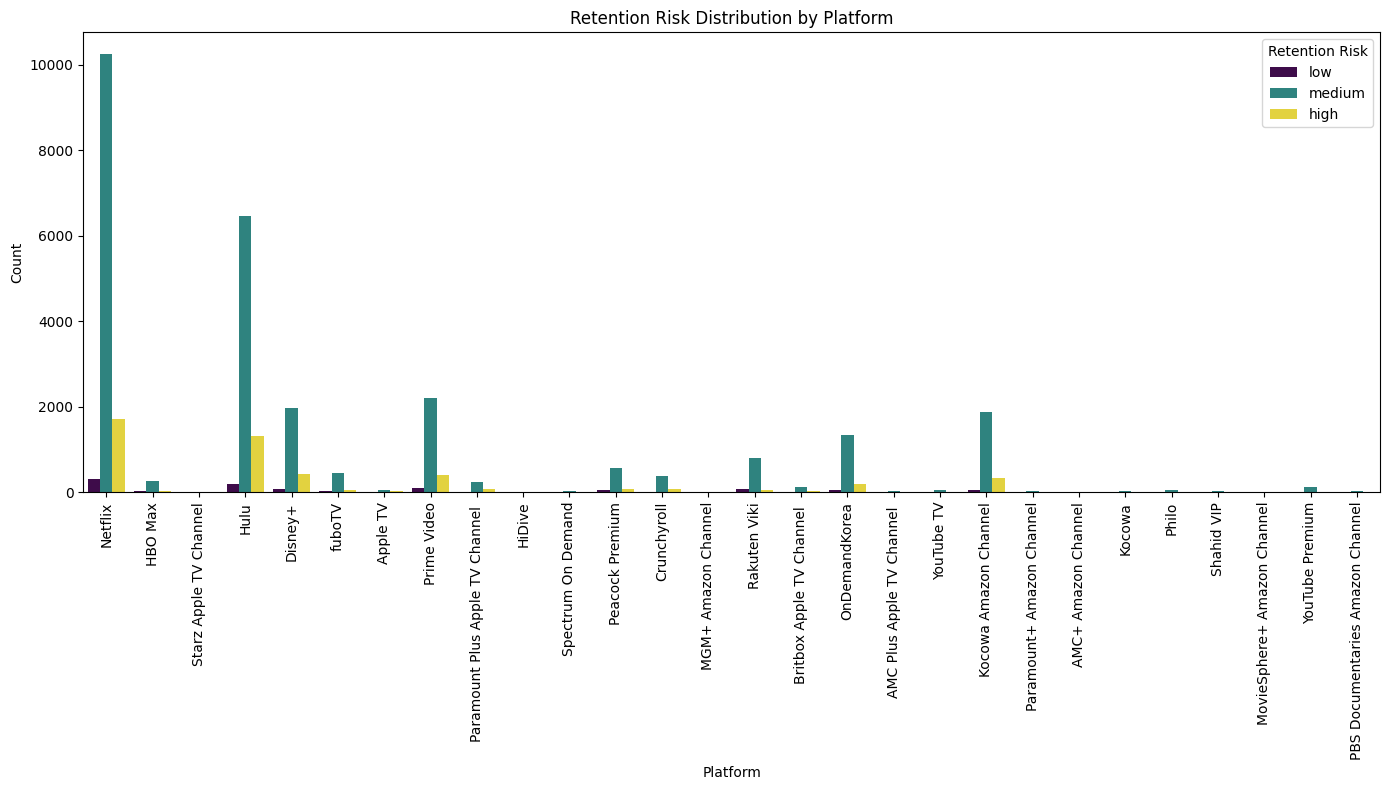

In [38]:
plt.figure(figsize=(14, 8))
# Create a count plot to visualize the distribution of retention risk across different platforms
sns.countplot(data=df, x='platform', hue='retention_risk', palette='viridis')
# Set the title of the plot
plt.title('Retention Risk Distribution by Platform')
# Set the label for the x-axis
plt.xlabel('Platform')
# Set the label for the y-axis
plt.ylabel('Count')
# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)
# Add a legend to explain the hue variable (retention_risk)
plt.legend(title='Retention Risk', labels=['low', 'medium', 'high'])
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()

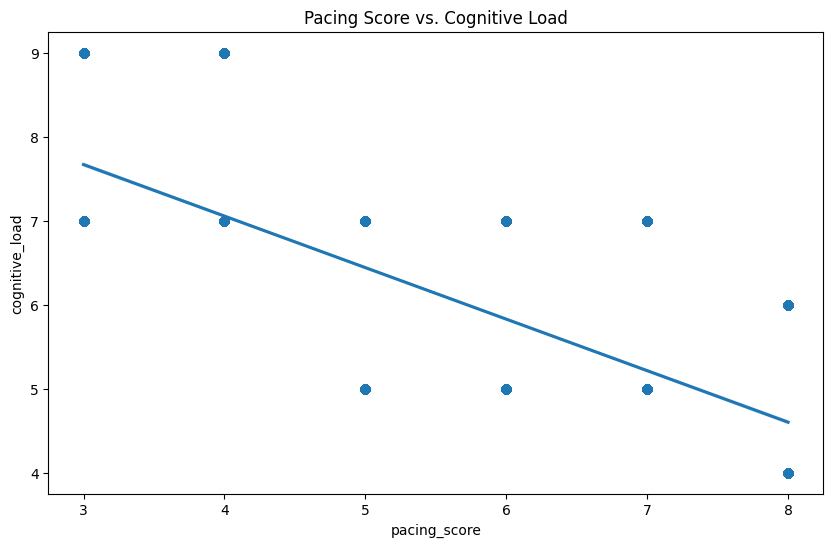

In [39]:
plt.figure(figsize=(10, 6))
# Create a regression plot to visualize the relationship between 'pacing_score' and 'cognitive_load'
sns.regplot(data=df, x='pacing_score', y='cognitive_load', scatter_kws={'alpha':0.3})
# Set the title of the plot
plt.title('Pacing Score vs. Cognitive Load')
# Display the plot
plt.show()

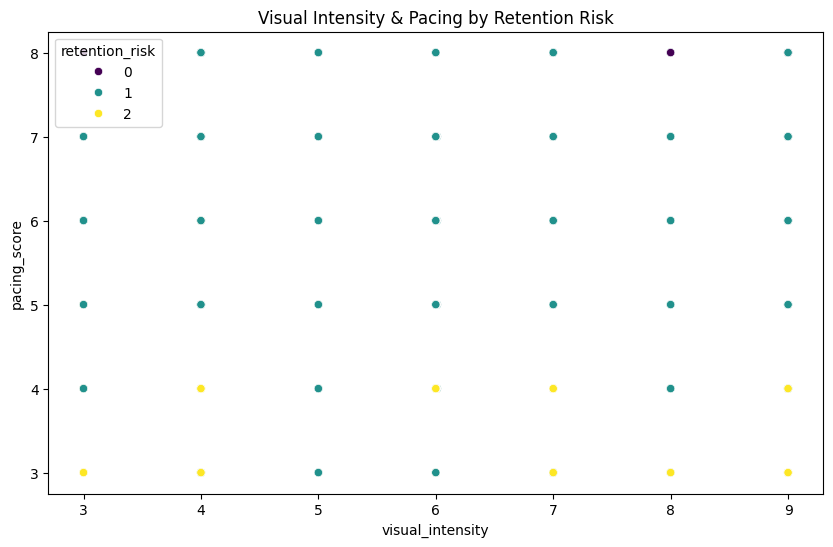

In [40]:
plt.figure(figsize=(10, 6))
# Create a scatter plot to visualize the relationship between 'visual_intensity' and 'pacing_score', colored by 'retention_risk'
sns.scatterplot(data=df, x='visual_intensity', y='pacing_score', hue='retention_risk', palette='viridis')
# Set the title of the plot
plt.title('Visual Intensity & Pacing by Retention Risk')
# Display the plot
plt.show()

<Figure size 1500x800 with 0 Axes>

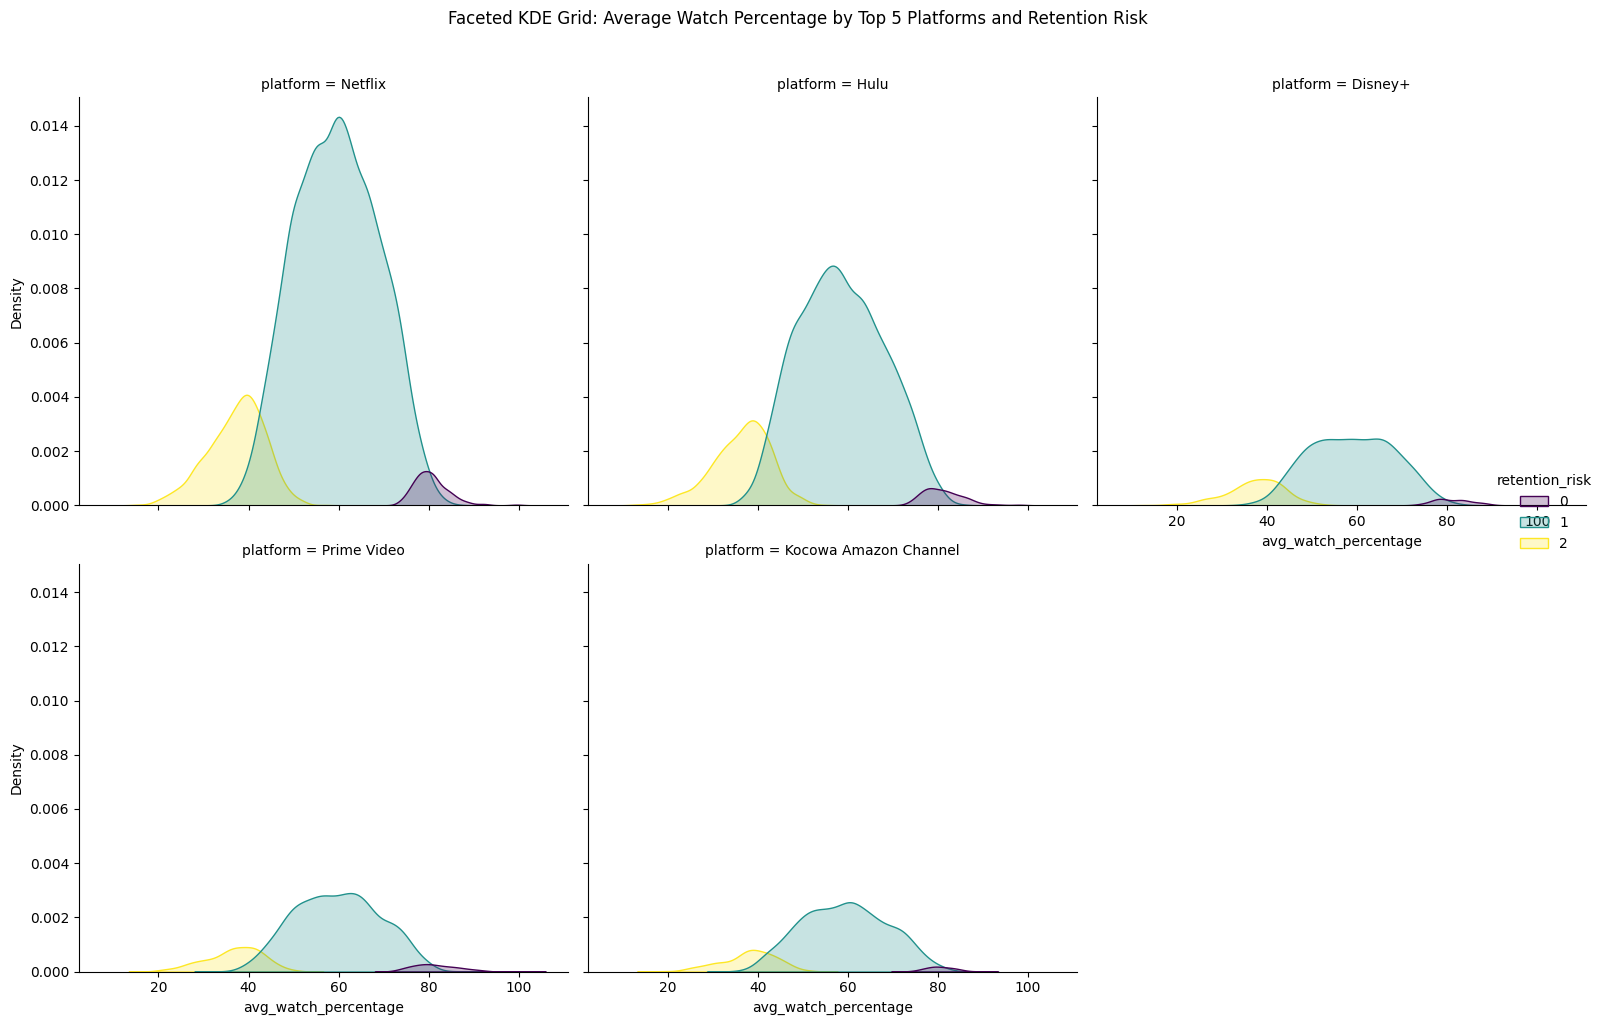

In [41]:
# Get the top 5 platforms by count
top_5_platforms = df['platform'].value_counts().head(5).index
# Filter the DataFrame to include only the top 5 platforms
df_top_5_platforms = df[df['platform'].isin(top_5_platforms)]

# Set the figure size for the plot
plt.figure(figsize=(15, 8))
# Create a faceted Kernel Density Estimate (KDE) plot
sns.displot(data=df_top_5_platforms, x='avg_watch_percentage', col='platform', hue='retention_risk', kind='kde', col_wrap=3, fill=True, palette='viridis')
# Set the super title for the entire grid of plots
plt.suptitle('Faceted KDE Grid: Average Watch Percentage by Top 5 Platforms and Retention Risk', y=1.02)
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()

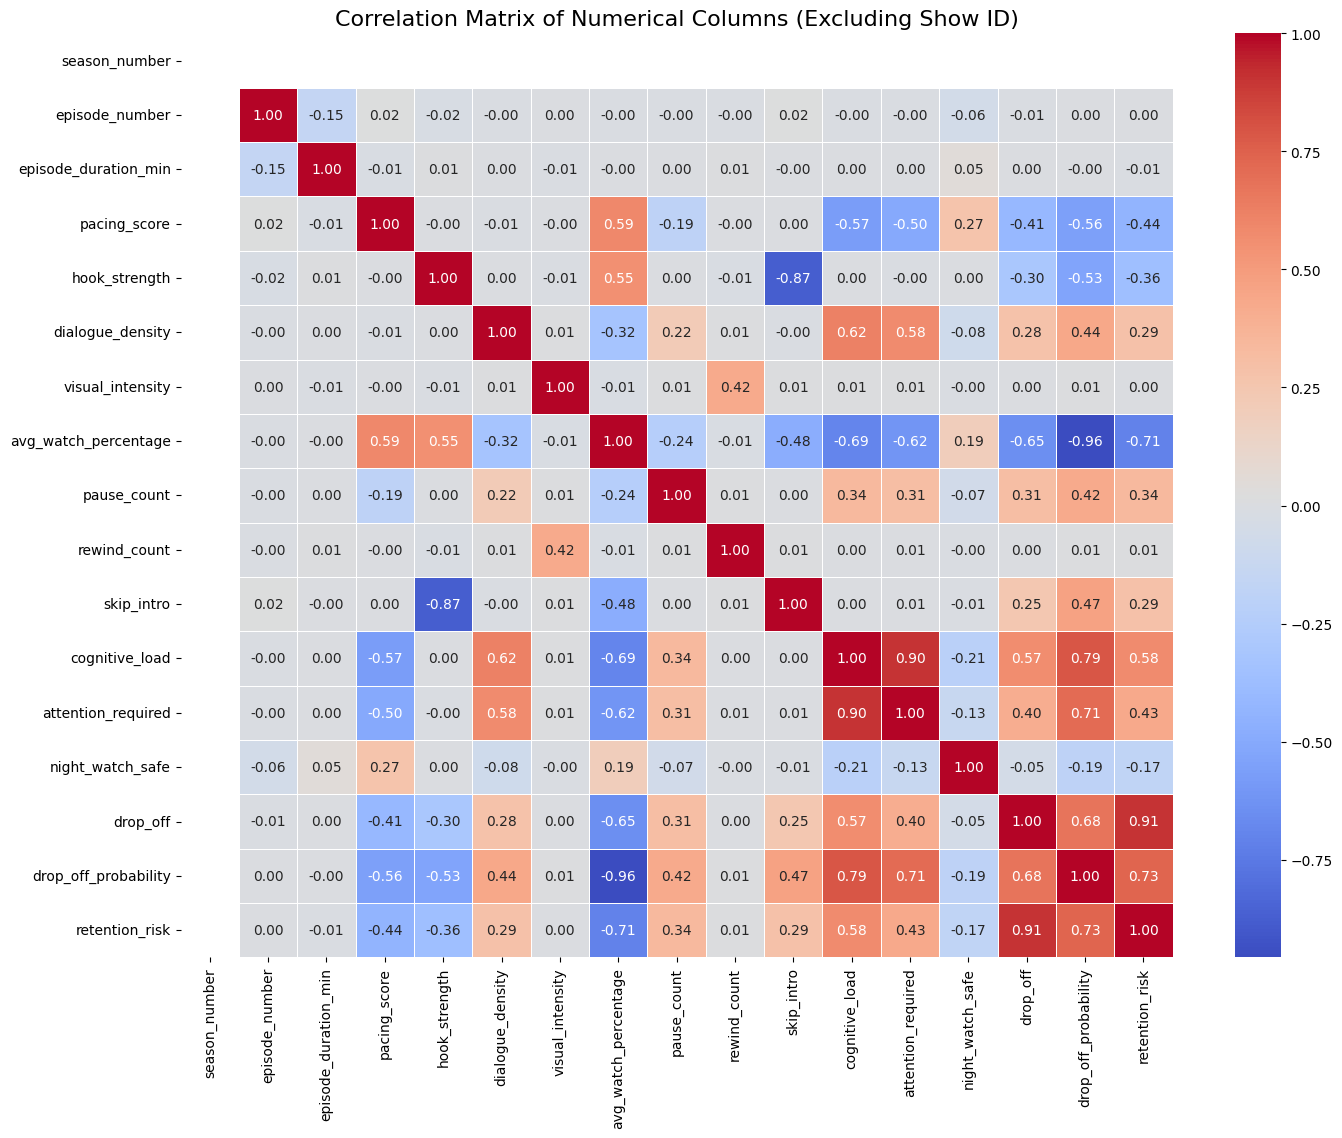

In [42]:
numerical_cols_df = df.select_dtypes(include=[np.number]).drop(columns=['show_id'], errors='ignore')

# Calculate the correlation matrix
corr_matrix = numerical_cols_df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns (Excluding Show ID)', fontsize=16)
plt.show()

In [45]:
print("Correlations with 'drop_off_probability':")
print(corr_matrix['drop_off_probability'].sort_values(ascending=False).head(5))
print("\nCorrelations with 'drop_off_probability' (least correlated / most negatively correlated):")
print(corr_matrix['drop_off_probability'].sort_values(ascending=True).head(5))

print("\nCorrelations with 'drop_off':")
print(corr_matrix['drop_off'].sort_values(ascending=False).head(5))
print("\nCorrelations with 'drop_off' (least correlated / most negatively correlated):")
print(corr_matrix['drop_off'].sort_values(ascending=True).head(5))

print("\nBased on the correlations:")
print("- 'avg_watch_percentage' has a strong negative correlation with 'drop_off_probability' and 'drop_off', meaning higher watch percentages are associated with lower drop-off.")
print("- 'retention_risk' (which was mapped as 0 for low, 1 for medium, 2 for high) shows a very strong positive correlation with 'drop_off_probability' and 'drop_off', indicating that higher retention risk is directly linked to higher drop-off.")
print("- 'episode_duration_min' and 'visual_intensity' also show some correlation with drop-off.")

Correlations with 'drop_off_probability':
drop_off_probability    1.000000
cognitive_load          0.793264
retention_risk          0.733449
attention_required      0.713535
drop_off                0.678664
Name: drop_off_probability, dtype: float64

Correlations with 'drop_off_probability' (least correlated / most negatively correlated):
avg_watch_percentage   -0.957093
pacing_score           -0.556766
hook_strength          -0.532716
night_watch_safe       -0.191544
episode_duration_min   -0.000182
Name: drop_off_probability, dtype: float64

Correlations with 'drop_off':
drop_off                1.000000
retention_risk          0.908259
drop_off_probability    0.678664
cognitive_load          0.569670
attention_required      0.404207
Name: drop_off, dtype: float64

Correlations with 'drop_off' (least correlated / most negatively correlated):
avg_watch_percentage   -0.645232
pacing_score           -0.413940
hook_strength          -0.304553
night_watch_safe       -0.052288
episode_numbe

In [47]:
# --- PHASE 3: Feature Engineering ---

# 1. Creating a composite engagement score
# This feature aims to capture active viewer engagement beyond just watch percentage,
# considering if they pause or rewind content.
# Arbitrary weights are used: 0.1 for rewinds and 0.05 for pauses.
df['engagement_score'] = df['avg_watch_percentage'] * (1 + df['rewind_count'] * 0.1 + df['pause_count'] * 0.05)

# 2. Creating a binary feature for 'binge_watcher'
# This categorizes viewers who watch a significantly high percentage of content,
# defined here as those in the top 25th percentile of 'avg_watch_percentage'.
threshold_avg_watch = df['avg_watch_percentage'].quantile(0.75)
df['binge_watcher'] = (df['avg_watch_percentage'] > threshold_avg_watch).astype(int)

# 3. Creating a 'content_challenge_index'
# This feature combines 'cognitive_load' and 'attention_required' (which is mapped 0/1 for medium/high)
# to reflect how challenging or demanding the content might be for a viewer.
# A weight of 5 is applied to 'attention_required' as it's a binary indicator.
df['content_challenge_index'] = df['cognitive_load'] + df['attention_required'] * 5

print("\nNewly created features:")
print(df[['engagement_score', 'binge_watcher', 'content_challenge_index']].head())

# Display the updated DataFrame info to show new columns
print("\nUpdated DataFrame info with new features:")
df.info()


Newly created features:
   engagement_score  binge_watcher  content_challenge_index
0             44.85              0                       14
1             79.75              0                        5
2             64.40              0                       14
3             65.00              0                       12
4             40.25              0                       12

Updated DataFrame info with new features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   show_id                  33171 non-null  int64         
 1   title                    33171 non-null  object        
 2   platform                 33171 non-null  object        
 3   genre                    33171 non-null  object        
 4   release_year             33171 non-null  datetime64[ns]
 5   season_number            33171 

In [49]:
## Calculating R² score to measure how much variance in viewer drop-off probability is explained by the model
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Linear Regression R² Score: {r2_lr:.4f}")
print(f"Random Forest R² Score: {r2_rf:.4f}")

Linear Regression R² Score: 0.9999
Random Forest R² Score: 0.9992


The very high R² values suggest that the features are highly predictive of viewer drop-off probability. However, extremely high scores may also indicate possible feature leakage or strong correlations within the dataset, which should be further investigated.

In [50]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R² Score": [r2_lr, r2_rf],
    "MAE": [mae_lr, mae_rf],
    "MSE": [mse_lr, mse_rf],
    "RMSE": [rmse_lr, rmse_rf]
})

comparison


,Model,R² Score,MAE,MSE,RMSE
0,Linear Regression,0.999902,0.000303,0.000001,0.001051
1,Random Forest,0.999159,0.000989,0.000010,0.003085


# Conclusion

This project explored the use of machine learning techniques to predict OTT viewer drop-off probability based on user behavior and content-related features. Through data preprocessing, exploratory data analysis, feature scaling, and model training, meaningful patterns within the dataset were identified.

Both Linear Regression and Random Forest Regressor models were implemented and evaluated using MAE, MSE, RMSE, and R² score. The results demonstrated strong predictive performance, indicating that viewer behavior can be effectively used to model drop-off probability.

The study highlights the importance of data-driven approaches in understanding user engagement and retention in OTT platforms. Future work may involve larger datasets, advanced machine learning models, and deep learning techniques to further improve predictive capability and real-world applicability.